# C-MAPSS Modeling — `modeling_v5_combined`
## Three models, one notebook: Improved LSTM · DANN · LSTM-GRL

**Course project:** 24-788 Introduction to Deep Learning (Spring 2026), 2-person team

**What this notebook contains, in order:**

| Section | Model | Task | Key change vs prior work |
|---|---|---|---|
| A (§1-§8) | **Improved LSTM** | FD001 RUL regression | hidden=128, 3 layers, Huber loss, layer norm |
| B (§9-§15) | **DANN** | FD001->FD002 domain adaptation | per-condition normalization fixes the upper bound |
| C (§16-§20) | **LSTM-GRL** | FD001->FD002 variant | GRL bolted onto the improved LSTM encoder, single model |
| D (§21) | **Final comparison** | All models on FD001 and FD002 | |

**Key improvements over v2/v4:**
- LSTM: hidden 64->128, layers 2->3, MSE->Huber loss (delta=20), LayerNorm after encoder, dropout 0.3->0.2
- FD002: per-operating-condition z-score normalization (k-means k=6 on settings) -- this is why the v4 upper bound was 53.8 RMSE instead of ~20s
- LSTM-GRL: the improved LSTM encoder gets a GRL domain head appended, trained jointly. No separate DANN class needed -- same encoder weights serve both tasks

**Hardware:** Apple Silicon (MPS), CUDA, or CPU fallback.


## §0 · Setup

In [1]:
import os, time, random, math, json, itertools
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

import torch
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Function
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from IPython.display import display, clear_output

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():        Device = "cuda"
elif torch.backends.mps.is_available(): Device = "mps"
else:                                Device = "cpu"
print(f"Device : {Device}")
print(f"PyTorch: {torch.__version__}")

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("CMAPSSData")
CKPT_DIR = Path("checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
FIG_DIR  = Path("figures");     FIG_DIR.mkdir(exist_ok=True)

assert DATA_DIR.exists(), "Place CMAPSSData/ next to this notebook."

Device : mps
PyTorch: 2.11.0


## §1 · Shared data constants and loading

Same sensor drop as v2. The new addition is `condition_normalize()` for FD002, which clusters engines into operating regimes using k-means on the 3 setting columns, then z-scores each sensor within each cluster. This is the standard preprocessing used by papers that report good FD002 numbers.

In [2]:
COLS        = (["unit", "cycle", "setting_1", "setting_2", "setting_3"]
               + [f"s_{i}" for i in range(1, 22)])
SENSORS_ALL = [c for c in COLS if c.startswith("s_")]
DROP_SENSORS = ["s_1", "s_5", "s_6", "s_10", "s_16", "s_18", "s_19"]
USE_SENSORS  = [s for s in SENSORS_ALL if s not in DROP_SENSORS]
SETTINGS     = ["setting_1", "setting_2", "setting_3"]

W        = 30
RUL_CLIP = 130

print(f"Using {len(USE_SENSORS)} sensors: {USE_SENSORS}")

def load_subset(subset: str):
    train = pd.read_csv(DATA_DIR / f"train_{subset}.txt", sep=r"\s+",
                        header=None, names=COLS, engine="python")
    test  = pd.read_csv(DATA_DIR / f"test_{subset}.txt",  sep=r"\s+",
                        header=None, names=COLS, engine="python")
    rul   = pd.read_csv(DATA_DIR / f"RUL_{subset}.txt",   sep=r"\s+",
                        header=None, names=["RUL"], engine="python")["RUL"].values
    return train, test, rul

def add_rul(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["RUL"] = df.groupby("unit")["cycle"].transform("max") - df["cycle"]
    return df

# ── Simple z-score normalization (used for FD001 and as DANN source stats) ────
def fit_normalize(df: pd.DataFrame):
    """Fit z-score on df[USE_SENSORS]. Returns (means, stds)."""
    means = df[USE_SENSORS].mean()
    stds  = df[USE_SENSORS].std().replace(0, 1.0)
    return means, stds

def apply_normalize(df: pd.DataFrame, means, stds) -> pd.DataFrame:
    df = df.copy()
    df[USE_SENSORS] = (df[USE_SENSORS] - means) / stds
    return df

# ── Per-condition normalization (used for FD002 supervised and LSTM-GRL target) ─
def condition_normalize(train_df: pd.DataFrame, test_df: pd.DataFrame,
                        n_clusters: int = 6, seed: int = SEED):
    """
    Cluster operating points by settings using k-means, then z-score each sensor
    within each cluster using train statistics only.

    FD002 has 6 operating conditions. k=6 recovers them exactly.
    FD001 has 1 condition -- condition_normalize with k=1 is identical to global z-score.

    Returns (train_normed, test_normed, kmeans) so the kmeans can be reused for
    normalizing new data at inference time.
    """
    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    km.fit(train_df[SETTINGS].values)

    train_out = train_df.copy()
    test_out  = test_df.copy()

    train_labels = km.predict(train_df[SETTINGS].values)
    test_labels  = km.predict(test_df[SETTINGS].values)

    train_out["_cond"] = train_labels
    test_out["_cond"]  = test_labels

    cluster_stats = {}  # cond -> (means, stds)
    for c in range(n_clusters):
        mask = train_out["_cond"] == c
        if mask.sum() == 0:
            continue
        m = train_out.loc[mask, USE_SENSORS].mean()
        s = train_out.loc[mask, USE_SENSORS].std().replace(0, 1.0)
        cluster_stats[c] = (m, s)
        train_out.loc[mask, USE_SENSORS] = (train_out.loc[mask, USE_SENSORS] - m) / s

    for c, (m, s) in cluster_stats.items():
        mask = test_out["_cond"] == c
        if mask.sum() == 0:
            continue
        test_out.loc[mask, USE_SENSORS] = (test_out.loc[mask, USE_SENSORS] - m) / s

    train_out = train_out.drop(columns=["_cond"])
    test_out  = test_out.drop(columns=["_cond"])
    return train_out, test_out, km, cluster_stats


# Load raw data
fd1_train_raw, fd1_test_raw, fd1_true_rul = load_subset("FD001")
fd2_train_raw, fd2_test_raw, fd2_true_rul = load_subset("FD002")

fd1_train_raw = add_rul(fd1_train_raw)
fd2_train_raw = add_rul(fd2_train_raw)

print(f"FD001: {fd1_train_raw['unit'].nunique()} train engines, {fd1_test_raw['unit'].nunique()} test engines")
print(f"FD002: {fd2_train_raw['unit'].nunique()} train engines, {fd2_test_raw['unit'].nunique()} test engines")

Using 14 sensors: ['s_2', 's_3', 's_4', 's_7', 's_8', 's_9', 's_11', 's_12', 's_13', 's_14', 's_15', 's_17', 's_20', 's_21']
FD001: 100 train engines, 100 test engines
FD002: 260 train engines, 259 test engines


In [3]:
# ── FD001: global z-score (1 condition, no clustering needed) ─────────────────
fd1_means, fd1_stds = fit_normalize(fd1_train_raw)
fd1_train = apply_normalize(fd1_train_raw, fd1_means, fd1_stds)
fd1_test  = apply_normalize(fd1_test_raw,  fd1_means, fd1_stds)

# ── FD002 supervised: per-condition z-score (6 conditions) ───────────────────
fd2_train_cond, fd2_test_cond, fd2_km, fd2_cluster_stats = condition_normalize(
    fd2_train_raw, fd2_test_raw, n_clusters=6
)

# ── FD002 for DANN source stats (unsupervised: FD001 stats applied to FD002) ──
# The DANN model never sees FD002 stats -- it uses FD001 normalization.
fd2_train_global = apply_normalize(fd2_train_raw, fd1_means, fd1_stds)
fd2_test_global  = apply_normalize(fd2_test_raw,  fd1_means, fd1_stds)

print("FD001 sensor check (should be ~0 mean, ~1 std):")
print(fd1_train[USE_SENSORS].describe().loc[["mean","std"]].T.round(3).head(4))
print()
print("FD002 condition-normed sensor check:")
print(fd2_train_cond[USE_SENSORS].describe().loc[["mean","std"]].T.round(3).head(4))

FD001 sensor check (should be ~0 mean, ~1 std):


/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/envs/main/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


     mean  std
s_2   0.0  1.0
s_3  -0.0  1.0
s_4   0.0  1.0
s_7  -0.0  1.0

FD002 condition-normed sensor check:
     mean  std
s_2  -0.0  1.0
s_3   0.0  1.0
s_4  -0.0  1.0
s_7  -0.0  1.0


## §2 · Dataset and windowing (shared)

Verbatim from v2/v4 -- nothing changes here.

In [4]:
class CMAPSSWindowDataset(Dataset):
    """Sliding-window dataset. One sample per (engine, end_cycle) pair."""
    def __init__(self, df: pd.DataFrame, sensors, window: int, rul_clip: int):
        self.X, self.y = [], []
        for _, eng in df.groupby("unit"):
            arr  = eng[sensors].values.astype(np.float32)
            ruls = np.minimum(eng["RUL"].values.astype(np.float32), rul_clip)
            L = len(arr)
            if L < window: continue
            for end in range(window, L + 1):
                self.X.append(arr[end - window : end])
                self.y.append(ruls[end - 1])
        self.X = np.stack(self.X)
        self.y = np.array(self.y, dtype=np.float32)

    def __len__(self):  return len(self.X)
    def __getitem__(self, i):
        return torch.from_numpy(self.X[i]), torch.tensor(self.y[i])


def build_test_windows(df: pd.DataFrame, sensors, window: int) -> np.ndarray:
    Xs = []
    for _, eng in df.groupby("unit"):
        arr = eng[sensors].values.astype(np.float32)
        if len(arr) >= window:
            Xs.append(arr[-window:])
        else:
            pad = np.tile(arr[0:1], (window - len(arr), 1))
            Xs.append(np.concatenate([pad, arr], axis=0))
    return np.stack(Xs)


# ── FD001 splits (used by all three models) ───────────────────────────────────
rng       = np.random.default_rng(SEED)
src_units = fd1_train["unit"].unique()
val_units = rng.choice(src_units, size=int(0.2 * len(src_units)), replace=False)
val_mask  = fd1_train["unit"].isin(val_units)

fd1_train_set = CMAPSSWindowDataset(fd1_train[~val_mask], USE_SENSORS, W, RUL_CLIP)
fd1_val_set   = CMAPSSWindowDataset(fd1_train[ val_mask], USE_SENSORS, W, RUL_CLIP)
X_test_fd1    = build_test_windows(fd1_test, USE_SENSORS, W)
y_test_fd1    = fd1_true_rul.astype(np.float32)

# ── FD002 splits ──────────────────────────────────────────────────────────────
# For DANN/LSTM-GRL: unlabeled target windows, globally normalized (FD001 stats)
tgt_train_set = CMAPSSWindowDataset(fd2_train_global, USE_SENSORS, W, RUL_CLIP)
X_test_fd2_global = build_test_windows(fd2_test_global, USE_SENSORS, W)

# For supervised upper bound: per-condition normalized
rng2          = np.random.default_rng(SEED)
fd2_units     = fd2_train_cond["unit"].unique()
fd2_val_u     = rng2.choice(fd2_units, size=int(0.2 * len(fd2_units)), replace=False)
fd2_val_mask  = fd2_train_cond["unit"].isin(fd2_val_u)
fd2_train_set = CMAPSSWindowDataset(fd2_train_cond[~fd2_val_mask], USE_SENSORS, W, RUL_CLIP)
fd2_val_set   = CMAPSSWindowDataset(fd2_train_cond[ fd2_val_mask], USE_SENSORS, W, RUL_CLIP)
X_test_fd2_cond = build_test_windows(fd2_test_cond, USE_SENSORS, W)
y_test_fd2      = fd2_true_rul.astype(np.float32)

print(f"FD001 train: {len(fd1_train_set):,} windows | val: {len(fd1_val_set):,} | test: {len(X_test_fd1)}")
print(f"FD002 tgt (unlabeled, global norm): {len(tgt_train_set):,} windows")
print(f"FD002 supervised (cond norm): train {len(fd2_train_set):,} | val {len(fd2_val_set):,} | test {len(X_test_fd2_cond)}")

FD001 train: 14,070 windows | val: 3,661 | test: 100
FD002 tgt (unlabeled, global norm): 46,219 windows
FD002 supervised (cond norm): train 37,174 | val 9,045 | test 259


## §3 · Shared evaluation utilities

In [5]:
def asymmetric_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    d = y_pred - y_true
    return float(np.where(d < 0, np.exp(-d/13.0)-1, np.exp(d/10.0)-1).sum())


def score_predictions(y_true: np.ndarray, y_pred_raw: np.ndarray, label: str = "") -> dict:
    y_pred = np.clip(y_pred_raw, 0, None)
    rmse   = math.sqrt(np.mean((y_pred - y_true) ** 2))
    score  = asymmetric_score(y_true, y_pred)
    mae    = float(np.mean(np.abs(y_pred - y_true)))
    bias   = float((y_pred - y_true).mean())
    if label: print(f"[{label}]")
    print(f"  RMSE  : {rmse:.3f}    Score : {score:.0f}    MAE : {mae:.3f}    Bias : {bias:+.3f}")
    return dict(rmse=rmse, score=score, mae=mae, bias=bias)


@torch.no_grad()
def run_inference(model, X: np.ndarray, device: str,
                  mode: str = "lstm", batch_size: int = 256) -> np.ndarray:
    """
    mode='lstm'  -> model(x) -- plain forward
    mode='dann'  -> model.predict_rul(x) -- DANN/LSTM-GRL inference path
    """
    model.eval()
    preds = []
    for i in range(0, len(X), batch_size):
        xb = torch.from_numpy(X[i:i+batch_size]).to(device)
        if mode == "lstm":
            preds.append(model(xb).cpu().numpy())
        else:
            preds.append(model.predict_rul(xb).cpu().numpy())
    return np.concatenate(preds)


@torch.no_grad()
def evaluate_loader(model, loader, device, mode="lstm"):
    model.eval()
    sq_err, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb) if mode == "lstm" else model.predict_rul(xb)
        sq_err += ((pred - yb)**2).sum().item()
        n += len(yb)
    return sq_err / n, math.sqrt(sq_err / n)

## §4 · Gradient Reversal Layer (shared by DANN and LSTM-GRL)

In [6]:
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.save_for_backward(torch.tensor(lam))
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        lam, = ctx.saved_tensors
        return -lam.item() * grad_output, None


class GradientReversalLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.lam = 0.0

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lam)


def ganin_lambda(epoch: int, n_epochs: int, high: float = 1.0) -> float:
    p = epoch / n_epochs
    return high * (2.0 / (1.0 + math.exp(-10.0 * p)) - 1.0)


print("GRL lambda ramp:")
for ep in [0, 5, 10, 20, 30, 40]:
    print(f"  ep {ep:2d}/40: lambda={ganin_lambda(ep, 40):.4f}")

GRL lambda ramp:
  ep  0/40: lambda=0.0000
  ep  5/40: lambda=0.5546
  ep 10/40: lambda=0.8483
  ep 20/40: lambda=0.9866
  ep 30/40: lambda=0.9989
  ep 40/40: lambda=0.9999


---
# Part A · Improved LSTM baseline (FD001)

Changes from v2:
- **hidden 64 -> 128**, **layers 2 -> 3**: more capacity for the longer sequences
- **Huber loss (delta=20)** instead of MSE: less sensitivity to large-RUL outliers in the healthy regime, which should reduce the systematic early-prediction bias
- **LayerNorm** after the LSTM output before the head: stabilizes training with 3 layers
- **dropout 0.3 -> 0.2**: 3 layers provide more implicit regularization
---

## §5 · Improved LSTM model

In [7]:
class ImprovedLSTM(nn.Module):
    """
    Deeper LSTM with LayerNorm and a wider head.
    Also serves as the encoder body for LSTM-GRL (Part C).
    """
    def __init__(self, n_features: int, hidden: int = 128,
                 num_layers: int = 3, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.norm = nn.LayerNorm(hidden)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Return the normalized last hidden state (B, H). Used by LSTM-GRL."""
        out, _ = self.lstm(x)       # (B, W, H)
        return self.norm(out[:, -1, :])  # (B, H)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encode(x)).squeeze(-1)


_m = ImprovedLSTM(len(USE_SENSORS)).to(Device)
_x = torch.randn(8, W, len(USE_SENSORS), device=Device)
print(f"Output shape : {tuple(_m(_x).shape)}  (expected (8,))")
print(f"Encode shape : {tuple(_m.encode(_x).shape)}  (expected (8, 128))")
print(f"Total params : {sum(p.numel() for p in _m.parameters()):,}")
del _m, _x

Output shape : (8,)  (expected (8,))
Encode shape : (8, 128)  (expected (8, 128))
Total params : 346,497


## §6 · TrainTracker (v2-style, reused across all three models)

In [8]:
class TrainTracker:
    def __init__(self, n_epochs: int, title: str = "", plot_freq: int = 1):
        self.n_epochs = n_epochs; self.plot_freq = plot_freq
        self.title    = title
        self.epoch    = 0
        self.train_loss, self.val_loss   = [], []
        self.train_rmse, self.val_rmse   = [], []
        self._stopped_at = None
        self.t0 = time.time()
        plt.ioff()
        self.fig, (self.ax_loss, self.ax_rmse) = plt.subplots(1, 2, figsize=(13, 4))
        self.tl, = self.ax_loss.plot([], [], label="train", color="steelblue")
        self.vl, = self.ax_loss.plot([], [], label="val",   color="darkorange")
        self.tr, = self.ax_rmse.plot([], [], label="train", color="steelblue")
        self.vr, = self.ax_rmse.plot([], [], label="val",   color="darkorange")
        for ax, ylabel in [(self.ax_loss, "Loss"), (self.ax_rmse, "Val RMSE (cycles)")]:
            ax.set_xlim(0, n_epochs + 1); ax.set_xlabel("Epoch")
            ax.set_ylabel(ylabel); ax.legend(); ax.grid(linestyle="--", alpha=0.6)
        self.ax_loss.set_title("Training loss")
        self.ax_rmse.set_title("RMSE")
        plt.tight_layout()

    def update_epoch(self, tl, vl, tr, vr):
        self.train_loss.append(tl); self.val_loss.append(vl)
        self.train_rmse.append(tr); self.val_rmse.append(vr)
        self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs:
            self._redraw()

    def mark_early_stop(self, epoch):
        self._stopped_at = epoch

    def _redraw(self):
        xs = list(range(1, self.epoch + 1))
        self.tl.set_data(xs, self.train_loss); self.vl.set_data(xs, self.val_loss)
        self.tr.set_data(xs, self.train_rmse); self.vr.set_data(xs, self.val_rmse)
        for ax in (self.ax_loss, self.ax_rmse):
            ax.relim(); ax.autoscale_view()
            if self._stopped_at:
                ax.axvline(self._stopped_at, color="crimson", linestyle=":", lw=1.5)
        elapsed = time.time() - self.t0
        eta     = (elapsed / self.epoch) * (self.n_epochs - self.epoch)
        suffix  = "  [early stop]" if self._stopped_at else ""
        self.fig.suptitle(
            f"{self.title}  Ep {self.epoch}/{self.n_epochs}  "
            f"val RMSE={self.val_rmse[-1]:.2f}  "
            f"elapsed {elapsed:.0f}s  ETA {eta:.0f}s{suffix}", fontsize=10)
        clear_output(wait=True); display(self.fig)

    def close(self): plt.close(self.fig)

## §7 · Generic training loop (LSTM)

Same structure as v2 with two additions: `loss_fn` parameter (supports Huber) and `model_mode` for routing `evaluate_loader` to the right forward path.

In [9]:
def train_lstm(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader:   DataLoader,
    n_epochs:     int   = 50,
    lr:           float = 5e-4,
    weight_decay: float = 1e-5,
    grad_clip:    float = 1.0,
    patience:     int   = 12,
    huber_delta:  float = 20.0,
    device:       str   = Device,
    ckpt_path:    Optional[Path] = None,
    tracker_title: str  = "",
):
    model    = model.to(device)
    opt      = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched    = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    crit     = nn.HuberLoss(delta=huber_delta)   # Huber instead of MSE
    mse_crit = nn.MSELoss(reduction="sum")        # for RMSE tracking only

    tracker    = TrainTracker(n_epochs, title=tracker_title)
    history    = []
    best_val   = float("inf")
    best_epoch = 0
    no_improve = 0

    pbar = tqdm(range(1, n_epochs + 1), desc=tracker_title or "Training", unit="epoch")
    for epoch in pbar:
        model.train()
        ep_loss, ep_sq, ep_n = 0.0, 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred   = model(xb)
            loss   = crit(pred, yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            ep_loss += loss.item() * len(yb)
            ep_sq   += ((pred - yb)**2).sum().item()
            ep_n    += len(yb)
        sched.step()

        train_loss = ep_loss / ep_n
        train_rmse = math.sqrt(ep_sq / ep_n)
        _, val_rmse = evaluate_loader(model, val_loader, device, mode="lstm")

        history.append(dict(epoch=epoch, train_loss=train_loss,
                            train_rmse=train_rmse, val_rmse=val_rmse,
                            lr=sched.get_last_lr()[0]))
        tracker.update_epoch(train_loss, train_loss, train_rmse, val_rmse)
        pbar.set_postfix({"val_RMSE": f"{val_rmse:.2f}", "no_imp": no_improve})

        if val_rmse < best_val:
            best_val, best_epoch, no_improve = val_rmse, epoch, 0
            if ckpt_path:
                torch.save({"model": model.state_dict(), "epoch": epoch,
                            "val_rmse": val_rmse}, ckpt_path)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch}.")
                tracker.mark_early_stop(epoch); tracker._redraw(); break

    tracker.close()
    print(f"Best val RMSE = {best_val:.3f} at epoch {best_epoch}")
    if ckpt_path and ckpt_path.exists():
        sd = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(sd["model"])
        print(f"Loaded best checkpoint (epoch {sd['epoch']}).")
    return model, pd.DataFrame(history)

## §8 · Train and evaluate improved LSTM on FD001

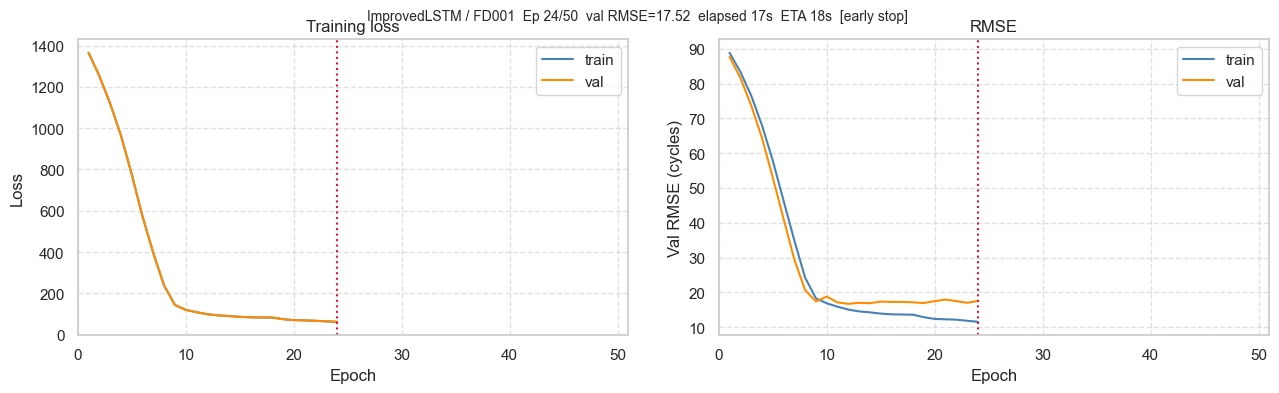

Best val RMSE = 16.681 at epoch 12
Loaded best checkpoint (epoch 12).


In [10]:
BATCH  = 512

fd1_train_loader = DataLoader(fd1_train_set, batch_size=BATCH, shuffle=True,  num_workers=0)
fd1_val_loader   = DataLoader(fd1_val_set,   batch_size=BATCH, shuffle=False, num_workers=0)

lstm_improved = ImprovedLSTM(n_features=len(USE_SENSORS))
print(f"ImprovedLSTM params: {sum(p.numel() for p in lstm_improved.parameters()):,}")

lstm_improved, lstm_history = train_lstm(
    lstm_improved, fd1_train_loader, fd1_val_loader,
    n_epochs=50, lr=5e-4, patience=12, huber_delta=20.0,
    device=Device,
    ckpt_path=CKPT_DIR / "lstm_improved_fd001.pt",
    tracker_title="ImprovedLSTM / FD001",
)

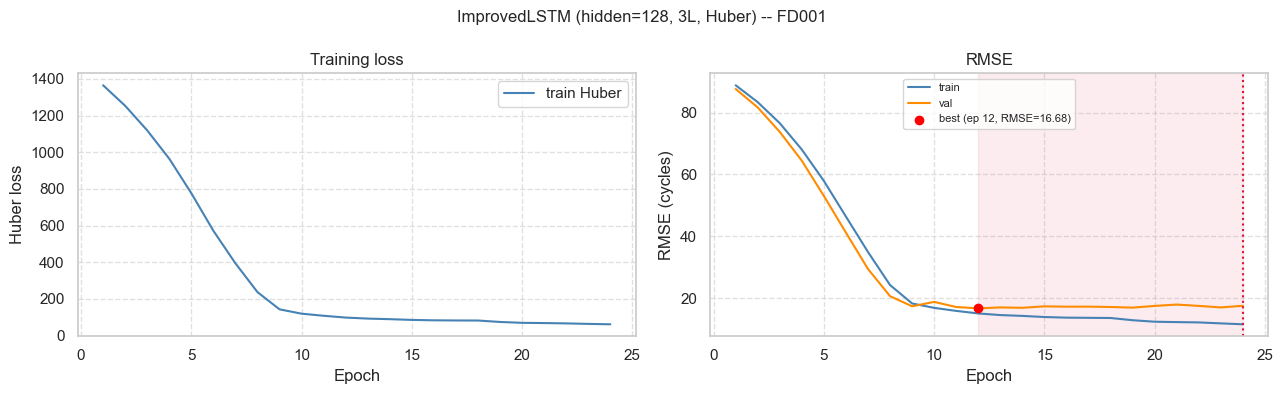

[ImprovedLSTM on FD001]
  RMSE  : 34.629    Score : 8804    MAE : 28.747    Bias : +19.376


In [11]:
# ── Training curves ────────────────────────────────────────────────────────────
best_idx = lstm_history["val_rmse"].idxmin()
best_ep  = lstm_history.loc[best_idx, "epoch"]
best_vr  = lstm_history.loc[best_idx, "val_rmse"]
stopped  = int(lstm_history["epoch"].iloc[-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(lstm_history["epoch"], lstm_history["train_loss"], color="steelblue", label="train Huber")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Huber loss"); ax1.set_title("Training loss")
ax1.legend(); ax1.grid(linestyle="--", alpha=0.6)

ax2.plot(lstm_history["epoch"], lstm_history["train_rmse"], color="steelblue", label="train")
ax2.plot(lstm_history["epoch"], lstm_history["val_rmse"],   color="darkorange", label="val")
ax2.scatter([best_ep], [best_vr], color="red", zorder=5,
            label=f"best (ep {best_ep}, RMSE={best_vr:.2f})")
if stopped < 50:
    ax2.axvspan(best_ep, stopped, alpha=0.08, color="crimson")
    ax2.axvline(stopped, color="crimson", linestyle=":", lw=1.5)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("RMSE (cycles)"); ax2.set_title("RMSE")
ax2.legend(fontsize=8); ax2.grid(linestyle="--", alpha=0.6)

plt.suptitle("ImprovedLSTM (hidden=128, 3L, Huber) -- FD001", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_improved_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Test evaluation ────────────────────────────────────────────────────────────
raw_lstm = run_inference(lstm_improved, X_test_fd1, Device, mode="lstm")
lstm_fd1_metrics = score_predictions(y_test_fd1, raw_lstm, "ImprovedLSTM on FD001")
lstm_history.to_csv(CKPT_DIR / "lstm_improved_history.csv", index=False)

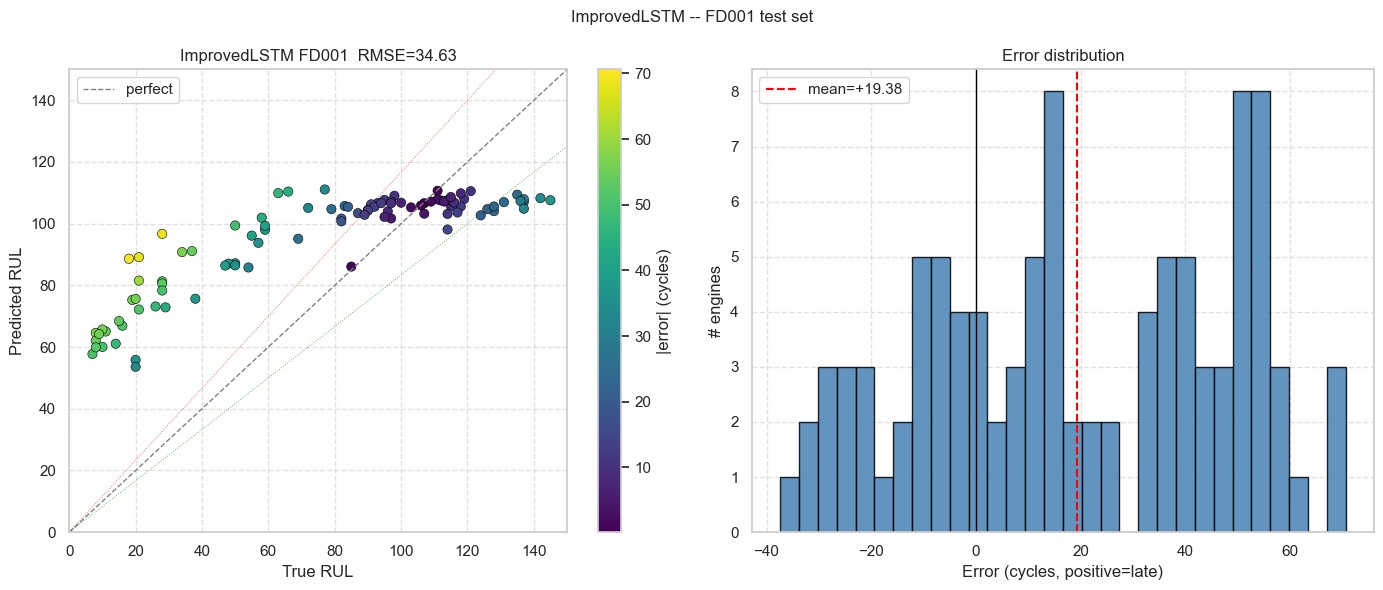

Bias (mean error) : +19.38 cycles
Std of errors     : 28.70
Within +/-10      : 21.0%

v2 baseline RMSE  : 20.70  Score: 663.7  Bias: -8.14
ImprovedLSTM RMSE : 34.63  Score: 8803.9  Bias: +19.38


In [12]:
# ── Scatter + error dist ───────────────────────────────────────────────────────
y_pred_lstm = np.clip(raw_lstm, 0, None)
errors_lstm = y_pred_lstm - y_test_fd1
lim = max(y_test_fd1.max(), y_pred_lstm.max()) + 5

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot([0,lim],[0,lim],"--",color="gray",lw=1,label="perfect")
ax.plot([0,lim],[0,lim-25],":",color="green",lw=0.7,alpha=0.6)
ax.plot([0,lim],[0,lim+25],":",color="red",lw=0.7,alpha=0.6)
sc = ax.scatter(y_test_fd1, y_pred_lstm, c=np.abs(errors_lstm),
                cmap="viridis", s=45, edgecolor="black", linewidth=0.4)
plt.colorbar(sc, ax=ax, label="|error| (cycles)")
ax.set_xlim(0,lim); ax.set_ylim(0,lim)
ax.set_xlabel("True RUL"); ax.set_ylabel("Predicted RUL")
ax.set_title(f"ImprovedLSTM FD001  RMSE={lstm_fd1_metrics['rmse']:.2f}")
ax.legend(); ax.grid(linestyle="--", alpha=0.6)

ax = axes[1]
ax.hist(errors_lstm, bins=30, color="steelblue", edgecolor="black", alpha=0.85)
ax.axvline(0, color="black", lw=1)
ax.axvline(errors_lstm.mean(), color="red", linestyle="--",
           label=f"mean={errors_lstm.mean():+.2f}")
ax.set_xlabel("Error (cycles, positive=late)"); ax.set_ylabel("# engines")
ax.set_title("Error distribution")
ax.legend(); ax.grid(linestyle="--", alpha=0.6)

plt.suptitle("ImprovedLSTM -- FD001 test set", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "lstm_improved_eval.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Bias (mean error) : {errors_lstm.mean():+.2f} cycles")
print(f"Std of errors     : {errors_lstm.std():.2f}")
print(f"Within +/-10      : {(np.abs(errors_lstm) <= 10).mean():.1%}")
print()
print(f"v2 baseline RMSE  : 20.70  Score: 663.7  Bias: -8.14")
print(f"ImprovedLSTM RMSE : {lstm_fd1_metrics['rmse']:.2f}  "
      f"Score: {lstm_fd1_metrics['score']:.1f}  "
      f"Bias: {lstm_fd1_metrics['bias']:+.2f}")

---
# Part B · DANN with per-condition normalization (FD001 -> FD002)

The key fix from v4: FD002 is now per-condition normalized before use in the supervised upper bound. The DANN itself still uses FD001 stats for target windows (unsupervised assumption -- no FD002 stats at adaptation time).

---

## §9 · DANN model (uses ImprovedLSTM encoder)

In [13]:
class DomainHead(nn.Module):
    """Binary domain classifier head. Sits after GRL."""
    def __init__(self, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, h): return self.net(h).squeeze(-1)


class DANNModel(nn.Module):
    """
    DANN built on top of ImprovedLSTM encoder.
    predict_rul(x) -> inference path (no GRL)
    forward(x_src, x_tgt) -> training path
    """
    def __init__(self, n_features: int, hidden: int = 128,
                 num_layers: int = 3, dropout: float = 0.2):
        super().__init__()
        self.encoder     = ImprovedLSTM(n_features, hidden, num_layers, dropout)
        self.domain_head = DomainHead(hidden)
        self.grl         = GradientReversalLayer()

    def predict_rul(self, x):
        return self.encoder(x)   # ImprovedLSTM.forward is the full RUL path

    def forward(self, x_src, x_tgt):
        h_src    = self.encoder.encode(x_src)          # (B_src, H)
        h_tgt    = self.encoder.encode(x_tgt)          # (B_tgt, H)
        rul_pred = self.encoder.head(h_src).squeeze(-1)  # (B_src,)
        h_all    = torch.cat([h_src, h_tgt], dim=0)
        dom_logits = self.domain_head(self.grl(h_all)) # (B_src+B_tgt,)
        return rul_pred, dom_logits


_m = DANNModel(len(USE_SENSORS)).to(Device)
_xs = torch.randn(8, W, len(USE_SENSORS), device=Device)
_xt = torch.randn(6, W, len(USE_SENSORS), device=Device)
_r, _d = _m(_xs, _xt)
print(f"RUL shape   : {tuple(_r.shape)}  (expected (8,))")
print(f"Domain shape: {tuple(_d.shape)}  (expected (14,))")
print(f"Total params: {sum(p.numel() for p in _m.parameters()):,}")
del _m, _xs, _xt, _r, _d

RUL shape   : (8,)  (expected (8,))
Domain shape: (14,)  (expected (14,))
Total params: 354,818


## §10 · DANN tracker (2x2 live plot)

In [14]:
class DANNTracker:
    def __init__(self, n_epochs, plot_freq=1):
        self.n_epochs = n_epochs; self.plot_freq = plot_freq
        self.epoch = 0
        self.total_loss, self.rul_loss, self.dom_loss, self.val_rmse, self.lam_hist = [], [], [], [], []
        self._stopped_at = None; self.t0 = time.time()
        plt.ioff()
        self.fig, axes = plt.subplots(2, 2, figsize=(13, 7))
        (self.ax_tot, self.ax_val), (self.ax_rul, self.ax_dom) = axes
        self.c_tot, = self.ax_tot.plot([], [], color="steelblue")
        self.c_val, = self.ax_val.plot([], [], color="darkorange")
        self.c_rul, = self.ax_rul.plot([], [], color="seagreen")
        self.c_dom, = self.ax_dom.plot([], [], color="mediumpurple", label="domain BCE")
        self.ax_dom2 = self.ax_dom.twinx()
        self.c_lam,  = self.ax_dom2.plot([], [], color="gray", linestyle="--", alpha=0.7)
        for ax, t, yl in [
            (self.ax_tot, "Total loss", "Loss"),
            (self.ax_val, "Val RMSE (FD001)", "RMSE (cycles)"),
            (self.ax_rul, "RUL loss (MSE on source)", "MSE"),
            (self.ax_dom, "Domain loss + lambda", "BCE loss"),
        ]:
            ax.set_title(t); ax.set_xlabel("Epoch"); ax.set_ylabel(yl)
            ax.set_xlim(0, n_epochs+1); ax.grid(linestyle="--", alpha=0.6)
        self.ax_dom2.set_ylabel("lambda")
        plt.tight_layout()

    def update_epoch(self, tot, rul, dom, vr, lam):
        self.total_loss.append(tot); self.rul_loss.append(rul)
        self.dom_loss.append(dom);   self.val_rmse.append(vr)
        self.lam_hist.append(lam);   self.epoch += 1
        if self.epoch % self.plot_freq == 0 or self.epoch == self.n_epochs:
            self._redraw()

    def mark_early_stop(self, ep): self._stopped_at = ep

    def _redraw(self):
        xs = list(range(1, self.epoch+1))
        for c, d, ax in [(self.c_tot, self.total_loss, self.ax_tot),
                          (self.c_val, self.val_rmse,  self.ax_val),
                          (self.c_rul, self.rul_loss,  self.ax_rul),
                          (self.c_dom, self.dom_loss,  self.ax_dom)]:
            c.set_data(xs, d); ax.relim(); ax.autoscale_view()
        self.c_lam.set_data(xs, self.lam_hist)
        self.ax_dom2.relim(); self.ax_dom2.autoscale_view()
        if self._stopped_at:
            for ax in (self.ax_tot, self.ax_val, self.ax_rul, self.ax_dom):
                ax.axvline(self._stopped_at, color="crimson", linestyle=":", lw=1.5)
        elapsed = time.time() - self.t0
        eta     = (elapsed/self.epoch) * (self.n_epochs - self.epoch)
        self.fig.suptitle(
            f"DANN  Ep {self.epoch}/{self.n_epochs}  val RMSE={self.val_rmse[-1]:.2f}  "
            f"lam={self.lam_hist[-1]:.3f}  elapsed {elapsed:.0f}s  ETA {eta:.0f}s"
            + ("  [early stop]" if self._stopped_at else ""), fontsize=10)
        clear_output(wait=True); display(self.fig)

    def close(self): plt.close(self.fig)

## §11 · DANN training loop

In [15]:
def train_dann(
    model: DANNModel,
    src_loader, tgt_loader, val_loader,
    n_epochs=40, lr=5e-4, weight_decay=1e-5,
    grad_clip=1.0, patience=12, lambda_max=1.0,
    device=Device, ckpt_path: Optional[Path]=None,
):
    model     = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched     = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    rul_crit  = nn.HuberLoss(delta=20.0)
    dom_crit  = nn.BCEWithLogitsLoss()

    tracker    = DANNTracker(n_epochs)
    history    = []
    best_val, best_ep, no_imp = float("inf"), 0, 0

    pbar = tqdm(range(1, n_epochs+1), desc="DANN", unit="epoch")
    for epoch in pbar:
        lam = ganin_lambda(epoch, n_epochs, high=lambda_max)
        model.grl.lam = lam
        model.train()
        ep_tot, ep_rul, ep_dom, ep_n = 0.0, 0.0, 0.0, 0

        tgt_iter = itertools.cycle(tgt_loader)
        for x_src, y_src in src_loader:
            x_tgt, _ = next(tgt_iter)
            x_src, y_src = x_src.to(device), y_src.to(device)
            x_tgt        = x_tgt.to(device)

            rul_pred, dom_logits = model(x_src, x_tgt)
            B_src = x_src.size(0); B_tgt = x_tgt.size(0)
            dom_labels = torch.cat([torch.zeros(B_src, device=device),
                                    torch.ones(B_tgt,  device=device)])

            l_rul = rul_crit(rul_pred, y_src)
            l_dom = dom_crit(dom_logits, dom_labels)
            loss  = l_rul + lam * l_dom

            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            ep_tot += loss.item()*B_src; ep_rul += l_rul.item()*B_src
            ep_dom += l_dom.item()*B_src; ep_n  += B_src

        sched.step()
        _, val_rmse = evaluate_loader(model, val_loader, device, mode="dann")

        history.append(dict(epoch=epoch, total_loss=ep_tot/ep_n,
                            rul_loss=ep_rul/ep_n, dom_loss=ep_dom/ep_n,
                            val_rmse=val_rmse, lam=lam,
                            lr=sched.get_last_lr()[0]))
        tracker.update_epoch(ep_tot/ep_n, ep_rul/ep_n, ep_dom/ep_n, val_rmse, lam)
        pbar.set_postfix({"val_RMSE": f"{val_rmse:.2f}", "lam": f"{lam:.3f}", "no_imp": no_imp})

        if val_rmse < best_val:
            best_val, best_ep, no_imp = val_rmse, epoch, 0
            if ckpt_path:
                torch.save({"model": model.state_dict(), "epoch": epoch,
                            "val_rmse": val_rmse, "lam": lam}, ckpt_path)
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"\nEarly stopping at epoch {epoch}.")
                tracker.mark_early_stop(epoch); tracker._redraw(); break

    tracker.close()
    print(f"Best val RMSE = {best_val:.3f} at epoch {best_ep}")
    if ckpt_path and ckpt_path.exists():
        sd = torch.load(ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(sd["model"])
        print(f"Loaded best checkpoint (epoch {sd['epoch']}).")
    return model, pd.DataFrame(history)

## §12 · Run 1 -- Lower bound: ImprovedLSTM evaluated naively on FD002

In [16]:
# ImprovedLSTM trained on FD001, evaluated on FD002 with FD001 normalization.
# No adaptation. This is the lower bound for the DANN experiment.
raw_lb = run_inference(lstm_improved, X_test_fd2_global, Device, mode="lstm")
lb_metrics = score_predictions(y_test_fd2, raw_lb, "Lower bound: ImprovedLSTM (FD001->FD002, no adapt.)")

[Lower bound: ImprovedLSTM (FD001->FD002, no adapt.)]
  RMSE  : 59.750    Score : 980501    MAE : 50.738    Bias : +27.882


## §13 · Run 2 -- Upper bound: ImprovedLSTM trained on labeled FD002 (per-condition normed)

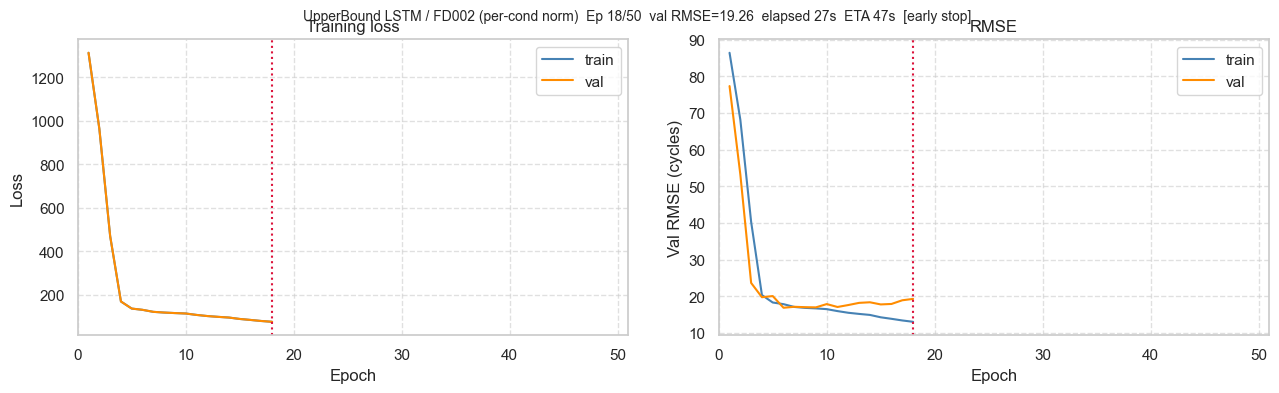

Best val RMSE = 16.848 at epoch 6
Loaded best checkpoint (epoch 6).
[Upper bound: ImprovedLSTM supervised on FD002]
  RMSE  : 46.830    Score : 67539    MAE : 38.811    Bias : -6.518


In [17]:
fd2_train_loader = DataLoader(fd2_train_set, batch_size=BATCH, shuffle=True,  num_workers=0)
fd2_val_loader   = DataLoader(fd2_val_set,   batch_size=BATCH, shuffle=False, num_workers=0)

lstm_ub = ImprovedLSTM(n_features=len(USE_SENSORS))
lstm_ub, ub_history = train_lstm(
    lstm_ub, fd2_train_loader, fd2_val_loader,
    n_epochs=50, lr=5e-4, patience=12, huber_delta=20.0,
    device=Device,
    ckpt_path=CKPT_DIR / "lstm_ub_fd002.pt",
    tracker_title="UpperBound LSTM / FD002 (per-cond norm)",
)

raw_ub = run_inference(lstm_ub, X_test_fd2_cond, Device, mode="lstm")
ub_metrics = score_predictions(y_test_fd2, raw_ub, "Upper bound: ImprovedLSTM supervised on FD002")
ub_history.to_csv(CKPT_DIR / "lstm_ub_fd002_history.csv", index=False)

## §14 · Run 3 -- DANN: FD001 -> FD002 unsupervised adaptation

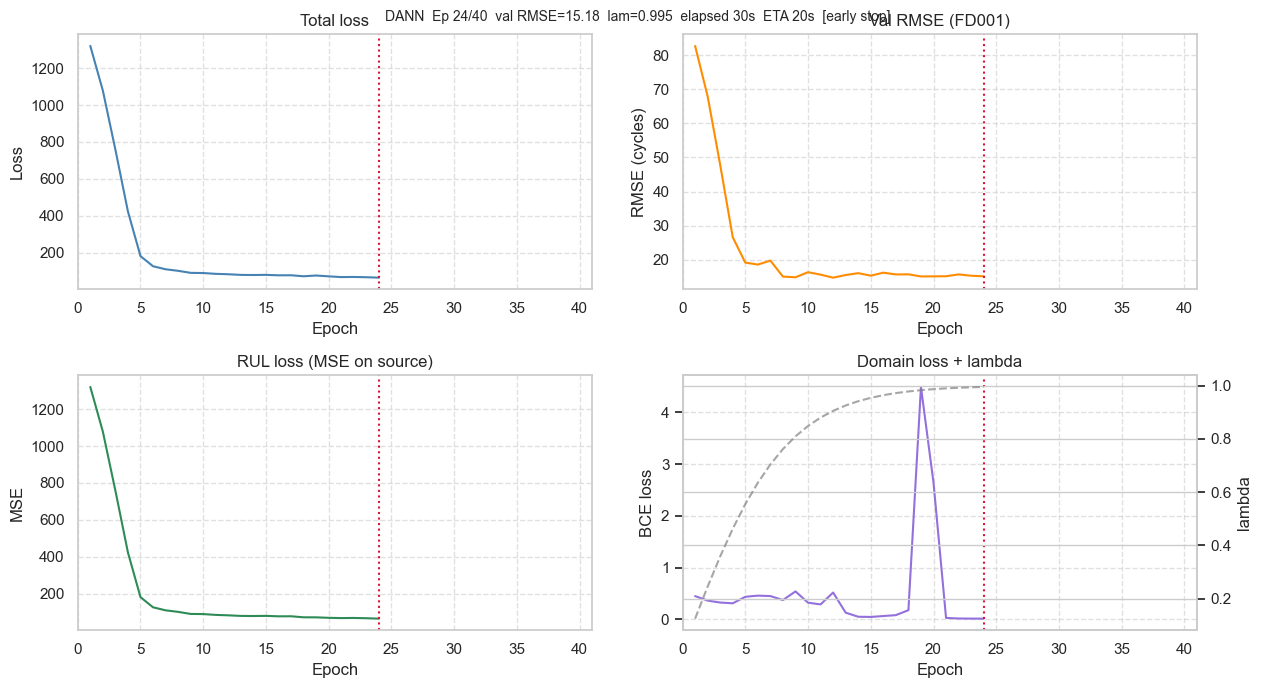

Best val RMSE = 14.778 at epoch 12
Loaded best checkpoint (epoch 12).
[DANN (FD001->FD002, unsupervised)]
  RMSE  : 55.920    Score : 434641    MAE : 47.956    Bias : +25.985


In [18]:
DANN_BATCH = 256

src_train_loader = DataLoader(fd1_train_set, batch_size=DANN_BATCH, shuffle=True,  num_workers=0)
tgt_train_loader = DataLoader(tgt_train_set, batch_size=DANN_BATCH, shuffle=True,  num_workers=0)
src_val_loader   = DataLoader(fd1_val_set,   batch_size=DANN_BATCH, shuffle=False, num_workers=0)

dann = DANNModel(n_features=len(USE_SENSORS))
print(f"DANN total params: {sum(p.numel() for p in dann.parameters()):,}")

dann, dann_history = train_dann(
    dann,
    src_loader=src_train_loader, tgt_loader=tgt_train_loader, val_loader=src_val_loader,
    n_epochs=40, lr=5e-4, patience=12, lambda_max=1.0,
    device=Device, ckpt_path=CKPT_DIR / "dann_fd001_fd002.pt",
)

# Evaluated on FD002 with FD001 normalization (no FD002 stats consumed)
raw_dann = run_inference(dann, X_test_fd2_global, Device, mode="dann")
dann_metrics = score_predictions(y_test_fd2, raw_dann, "DANN (FD001->FD002, unsupervised)")
dann_history.to_csv(CKPT_DIR / "dann_history.csv", index=False)

## §15 · DANN three-way comparison

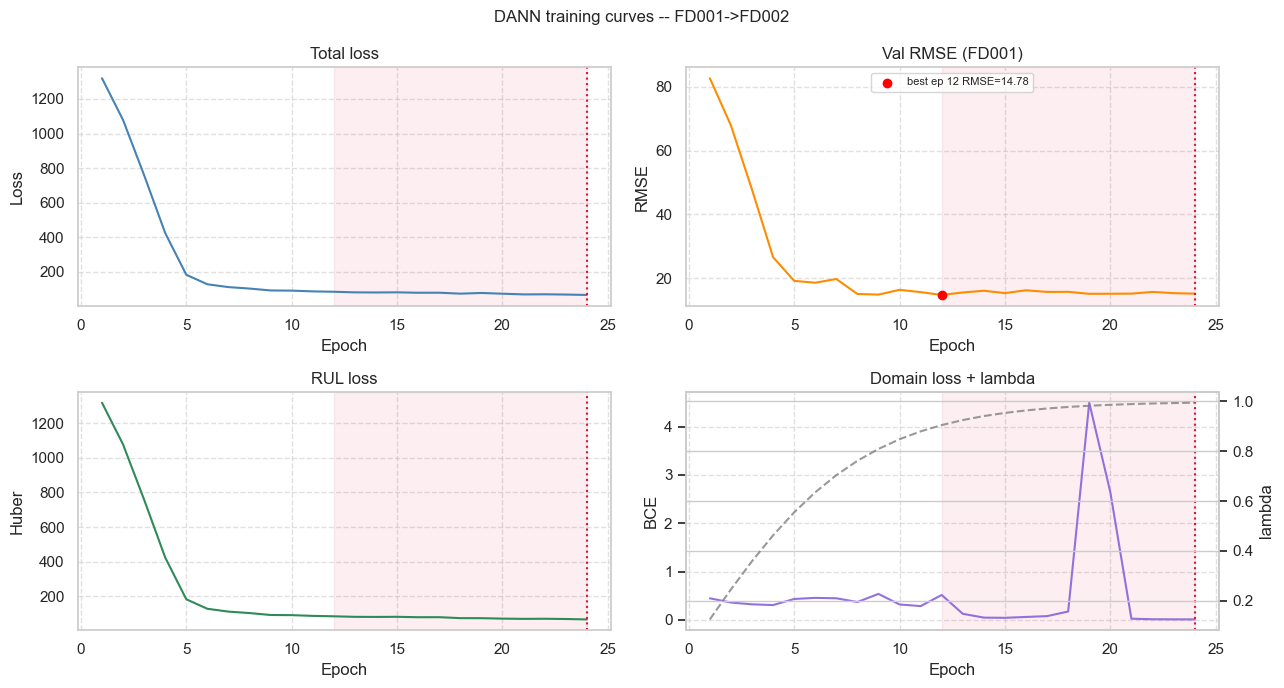

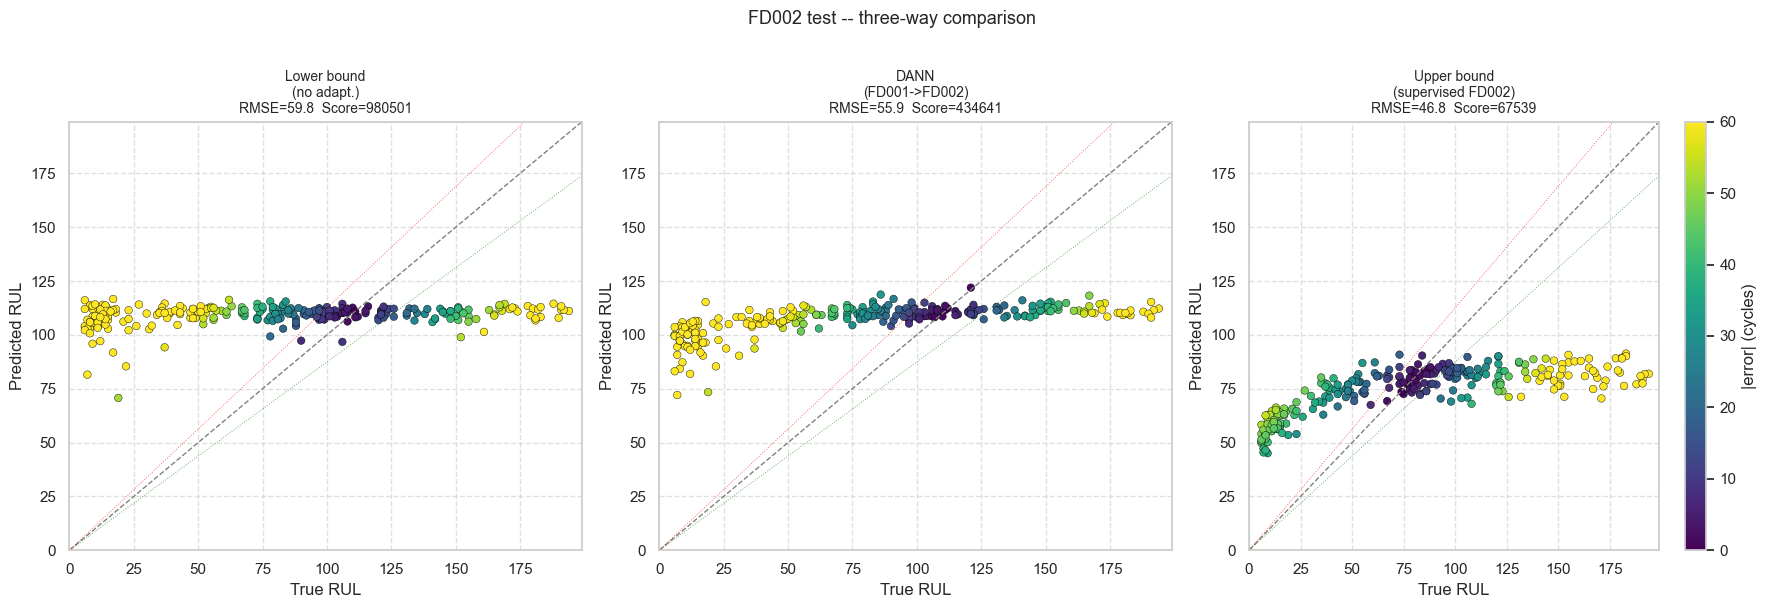


DANN closed 29.6% of the RMSE gap and 59.8% of the score gap.


In [19]:
# ── Training curves ────────────────────────────────────────────────────────────
dann_best_idx = dann_history["val_rmse"].idxmin()
dann_best_ep  = dann_history.loc[dann_best_idx, "epoch"]
dann_best_vr  = dann_history.loc[dann_best_idx, "val_rmse"]
dann_stopped  = int(dann_history["epoch"].iloc[-1])

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
(ax_tot, ax_val), (ax_rul, ax_dom) = axes

ax_tot.plot(dann_history["epoch"], dann_history["total_loss"], color="steelblue")
ax_val.plot(dann_history["epoch"], dann_history["val_rmse"],   color="darkorange")
ax_val.scatter([dann_best_ep], [dann_best_vr], color="red", zorder=5,
               label=f"best ep {dann_best_ep} RMSE={dann_best_vr:.2f}")
ax_rul.plot(dann_history["epoch"], dann_history["rul_loss"],   color="seagreen")
ax_dom.plot(dann_history["epoch"], dann_history["dom_loss"],   color="mediumpurple", label="BCE")
ax_dom2 = ax_dom.twinx()
ax_dom2.plot(dann_history["epoch"], dann_history["lam"],
             color="gray", linestyle="--", alpha=0.8, label="lambda")
ax_dom2.set_ylabel("lambda")

for ax, t, yl in [(ax_tot,"Total loss","Loss"),(ax_val,"Val RMSE (FD001)","RMSE"),
                   (ax_rul,"RUL loss","Huber"),(ax_dom,"Domain loss + lambda","BCE")]:
    ax.set_title(t); ax.set_xlabel("Epoch"); ax.set_ylabel(yl)
    ax.grid(linestyle="--", alpha=0.6)
    if dann_stopped < 40:
        ax.axvline(dann_stopped, color="crimson", linestyle=":", lw=1.5)
        ax.axvspan(dann_best_ep, dann_stopped, alpha=0.07, color="crimson")

ax_val.legend(fontsize=8)
plt.suptitle(f"DANN training curves -- FD001->FD002", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "dann_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Three-way scatter ──────────────────────────────────────────────────────────
models_info = [
    ("Lower bound\n(no adapt.)",          np.clip(raw_lb,   0, None), lb_metrics),
    ("DANN\n(FD001->FD002)",              np.clip(raw_dann, 0, None), dann_metrics),
    ("Upper bound\n(supervised FD002)",   np.clip(raw_ub,   0, None), ub_metrics),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
lim = max(y_test_fd2.max(), max(p.max() for _, p, _ in models_info)) + 5

for ax, (title, yp, m) in zip(axes, models_info):
    ax.plot([0,lim],[0,lim],"--",color="gray",lw=1)
    ax.plot([0,lim],[0,lim-25],":",color="green",lw=0.7,alpha=0.6)
    ax.plot([0,lim],[0,lim+25],":",color="red",lw=0.7,alpha=0.6)
    errs = np.abs(yp - y_test_fd2)
    sc = ax.scatter(y_test_fd2, yp, c=errs, cmap="viridis",
                    s=30, edgecolor="black", linewidth=0.3, vmin=0, vmax=60)
    ax.set_xlim(0,lim); ax.set_ylim(0,lim)
    ax.set_xlabel("True RUL"); ax.set_ylabel("Predicted RUL")
    ax.set_title(f"{title}\nRMSE={m['rmse']:.1f}  Score={m['score']:.0f}", fontsize=10)
    ax.grid(linestyle="--", alpha=0.6)

plt.colorbar(sc, ax=axes[-1], label="|error| (cycles)")
plt.suptitle("FD002 test -- three-way comparison", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "dann_threeway.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Gap analysis ───────────────────────────────────────────────────────────────
gap_rmse  = (lb_metrics['rmse']  - dann_metrics['rmse'])  / (lb_metrics['rmse']  - ub_metrics['rmse'])  * 100
gap_score = (lb_metrics['score'] - dann_metrics['score']) / (lb_metrics['score'] - ub_metrics['score']) * 100
print(f"\nDANN closed {gap_rmse:.1f}% of the RMSE gap and {gap_score:.1f}% of the score gap.")

---
# Part C · LSTM-GRL variant

**The idea.** Instead of keeping the domain head as a separate DANN class, we bolt the GRL domain head directly onto the `ImprovedLSTM` encoder using a `LSTMWithGRL` wrapper. This is a single model with one optimizer, one training loop, and one checkpoint. At inference time the GRL is zeroed out (lambda=0) so it is a pure RUL predictor.

**Why this is different from DANN:**
- DANN uses the full `ImprovedLSTM` (encoder + head) as its RUL branch, with the GRL attached to the encoder's hidden state
- LSTM-GRL is the same architecture but framed as a *variant* of the LSTM rather than a separate DANN system -- the emphasis is on what the GRL does to the LSTM's representations, not on the domain adaptation pipeline
- Same loss: `L_rul (Huber) + lambda * L_dom (BCE)`
- Same Ganin ramp
- Evaluated on FD002 the same way as DANN (FD001 normalization, no FD002 stats)

---

## §16 · LSTM-GRL model

In [20]:
class LSTMWithGRL(nn.Module):
    """
    ImprovedLSTM extended with a GRL domain head.

    Training: forward(x_src, x_tgt) -> (rul_pred, domain_logits)
    Inference: predict_rul(x) OR forward_rul(x) -- GRL is live but lambda=0
               so it is a pure pass-through and domain head is unused.

    The key difference from DANNModel: the ImprovedLSTM.head (RUL head) and
    the domain head share the *same* encoder.encode() output. The GRL inverts
    gradients flowing back through the domain branch, pushing the encoder to
    produce domain-invariant features while still minimizing RUL loss.
    """
    def __init__(self, n_features: int, hidden: int = 128,
                 num_layers: int = 3, dropout: float = 0.2):
        super().__init__()
        self.lstm_body   = ImprovedLSTM(n_features, hidden, num_layers, dropout)
        self.domain_head = DomainHead(hidden)
        self.grl         = GradientReversalLayer()

    def predict_rul(self, x: torch.Tensor) -> torch.Tensor:
        """Inference path -- identical to ImprovedLSTM.forward."""
        return self.lstm_body(x)

    def forward(self, x_src: torch.Tensor, x_tgt: torch.Tensor):
        """
        Training forward:
          1. Encode both source and target through the shared LSTM encoder.
          2. Source hidden state -> RUL head.
          3. Concatenated hidden states -> GRL -> domain head.
        """
        h_src = self.lstm_body.encode(x_src)   # (B_src, H)
        h_tgt = self.lstm_body.encode(x_tgt)   # (B_tgt, H)

        rul_pred   = self.lstm_body.head(h_src).squeeze(-1)         # (B_src,)
        h_all      = torch.cat([h_src, h_tgt], dim=0)               # (B_src+B_tgt, H)
        dom_logits = self.domain_head(self.grl(h_all))              # (B_src+B_tgt,)

        return rul_pred, dom_logits


_m = LSTMWithGRL(len(USE_SENSORS)).to(Device)
_xs = torch.randn(8, W, len(USE_SENSORS), device=Device)
_xt = torch.randn(6, W, len(USE_SENSORS), device=Device)
_r, _d = _m(_xs, _xt)
print(f"RUL shape   : {tuple(_r.shape)}")
print(f"Domain shape: {tuple(_d.shape)}")
print(f"Params      : {sum(p.numel() for p in _m.parameters()):,}")
del _m, _xs, _xt, _r, _d

RUL shape   : (8,)
Domain shape: (14,)
Params      : 354,818


## §17 · LSTM-GRL training loop

Reuses `train_dann()` exactly -- the interface is identical because `LSTMWithGRL` and `DANNModel` both expose `forward(x_src, x_tgt)` and `predict_rul(x)` and carry a `.grl` attribute.

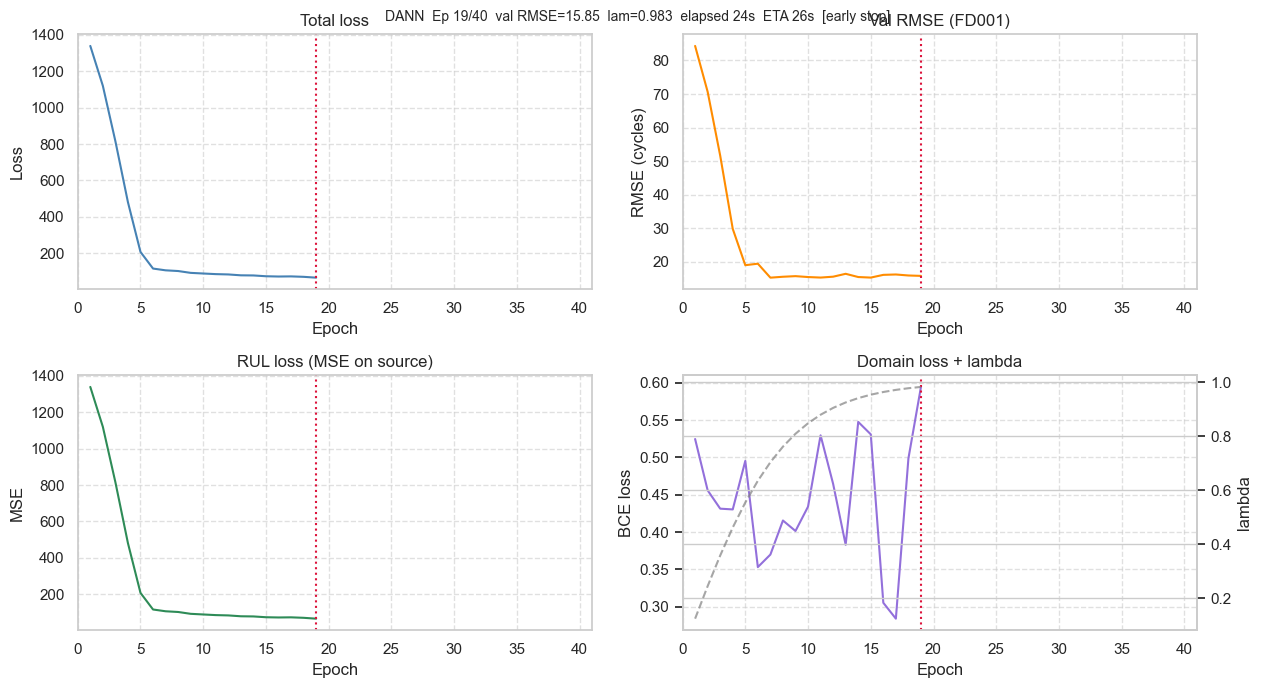

Best val RMSE = 15.326 at epoch 7
Loaded best checkpoint (epoch 7).
[LSTM-GRL (FD001->FD002, unsupervised)]
  RMSE  : 67.128    Score : 3472826    MAE : 57.350    Bias : +42.886


In [21]:
lstm_grl = LSTMWithGRL(n_features=len(USE_SENSORS))
print(f"LSTM-GRL total params: {sum(p.numel() for p in lstm_grl.parameters()):,}")

lstm_grl, grl_history = train_dann(
    lstm_grl,
    src_loader=src_train_loader, tgt_loader=tgt_train_loader, val_loader=src_val_loader,
    n_epochs=40, lr=5e-4, patience=12, lambda_max=1.0,
    device=Device, ckpt_path=CKPT_DIR / "lstm_grl_fd001_fd002.pt",
)

raw_grl = run_inference(lstm_grl, X_test_fd2_global, Device, mode="dann")
grl_metrics = score_predictions(y_test_fd2, raw_grl, "LSTM-GRL (FD001->FD002, unsupervised)")
grl_history.to_csv(CKPT_DIR / "lstm_grl_history.csv", index=False)

## §18 · Also evaluate LSTM-GRL on FD001 (its source domain)

In [22]:
raw_grl_fd1 = run_inference(lstm_grl, X_test_fd1, Device, mode="dann")
grl_fd1_metrics = score_predictions(y_test_fd1, raw_grl_fd1, "LSTM-GRL on FD001 (source domain)")

[LSTM-GRL on FD001 (source domain)]
  RMSE  : 17.311    Score : 735    MAE : 13.336    Bias : +4.725


## §19 · DANN vs LSTM-GRL comparison on FD002

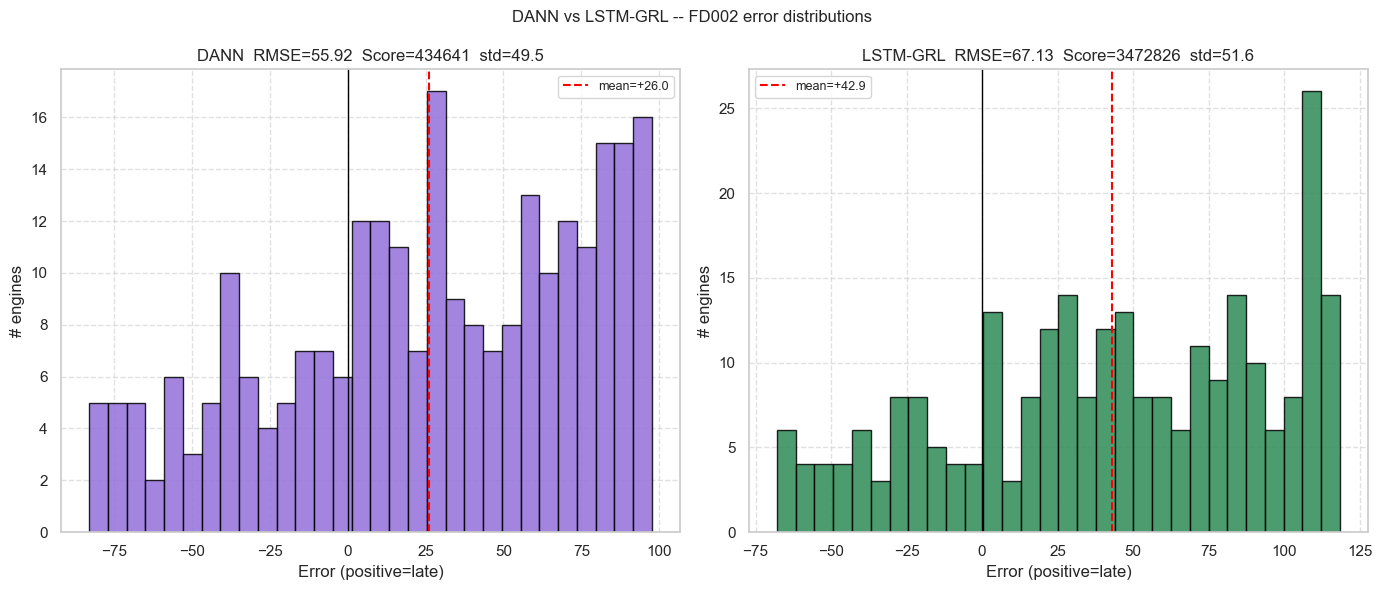

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
preds_compare = [
    ("DANN", np.clip(raw_dann, 0, None), dann_metrics, "mediumpurple"),
    ("LSTM-GRL", np.clip(raw_grl, 0, None), grl_metrics, "seagreen"),
]

for ax, (name, yp, m, color) in zip(axes, preds_compare):
    errs = yp - y_test_fd2
    ax.hist(errs, bins=30, color=color, edgecolor="black", alpha=0.85)
    ax.axvline(0,           color="black",  lw=1)
    ax.axvline(errs.mean(), color="red",    lw=1.5, linestyle="--",
               label=f"mean={errs.mean():+.1f}")
    ax.set_xlabel("Error (positive=late)"); ax.set_ylabel("# engines")
    ax.set_title(f"{name}  RMSE={m['rmse']:.2f}  Score={m['score']:.0f}  std={errs.std():.1f}")
    ax.legend(fontsize=9); ax.grid(linestyle="--", alpha=0.6)

plt.suptitle("DANN vs LSTM-GRL -- FD002 error distributions", fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / "dann_vs_grl.png", dpi=150, bbox_inches="tight")
plt.show()

---
# Part D · Final comparison table and figures
---

## §20 · FD001 comparison (LSTM v2 vs ImprovedLSTM vs LSTM-GRL source domain)

In [24]:
# Load v2 results if available for the table
v2_res_path = CKPT_DIR / "lstm_v2_FD001_results.json"
if v2_res_path.exists():
    with open(v2_res_path) as f:
        v2_res = json.load(f)
    v2_rmse  = v2_res["test_rmse"]
    v2_score = v2_res["test_score"]
    v2_bias  = v2_res["test_bias"]
else:
    v2_rmse, v2_score, v2_bias = 20.702, 663.7, -8.138
    print("(v2 results loaded from hardcoded values -- run modeling_v2 to regenerate)")

fd1_table = pd.DataFrame([
    {"Model": "LSTM v2 (baseline)",    "RMSE": v2_rmse,                        "Score": v2_score,                        "Bias": v2_bias},
    {"Model": "ImprovedLSTM",          "RMSE": lstm_fd1_metrics["rmse"],        "Score": lstm_fd1_metrics["score"],        "Bias": lstm_fd1_metrics["bias"]},
    {"Model": "LSTM-GRL (src domain)", "RMSE": grl_fd1_metrics["rmse"],         "Score": grl_fd1_metrics["score"],         "Bias": grl_fd1_metrics["bias"]},
    {"Model": "Zheng et al. (2017)",   "RMSE": 16.1,                            "Score": 339.0,                           "Bias": float("nan")},
])
print("FD001 Test Results:")
print(fd1_table.to_string(index=False, float_format="{:.2f}".format))

FD001 Test Results:
                Model  RMSE   Score  Bias
   LSTM v2 (baseline) 20.70  663.67 -8.14
         ImprovedLSTM 34.63 8803.94 19.38
LSTM-GRL (src domain) 17.31  734.52  4.73
  Zheng et al. (2017) 16.10  339.00   NaN


## §21 · FD002 comparison (lower bound / DANN / LSTM-GRL / upper bound)

In [25]:
gap_dann_rmse  = (lb_metrics['rmse']  - dann_metrics['rmse'])  / (lb_metrics['rmse']  - ub_metrics['rmse'])  * 100
gap_dann_score = (lb_metrics['score'] - dann_metrics['score']) / (lb_metrics['score'] - ub_metrics['score']) * 100
gap_grl_rmse   = (lb_metrics['rmse']  - grl_metrics['rmse'])   / (lb_metrics['rmse']  - ub_metrics['rmse'])  * 100
gap_grl_score  = (lb_metrics['score'] - grl_metrics['score'])  / (lb_metrics['score'] - ub_metrics['score']) * 100

fd2_table = pd.DataFrame([
    {"Model": "Lower bound (no adapt.)", "Train data": "FD001 labeled",
     "RMSE": lb_metrics['rmse'],   "Score": lb_metrics['score'],
     "MAE":  lb_metrics['mae'],    "Bias":  lb_metrics['bias'],   "Gap closed (RMSE)": "--"},
    {"Model": "DANN",                    "Train data": "FD001 + FD002 unlabeled",
     "RMSE": dann_metrics['rmse'], "Score": dann_metrics['score'],
     "MAE":  dann_metrics['mae'],  "Bias":  dann_metrics['bias'],
     "Gap closed (RMSE)": f"{gap_dann_rmse:.1f}%"},
    {"Model": "LSTM-GRL",               "Train data": "FD001 + FD002 unlabeled",
     "RMSE": grl_metrics['rmse'],  "Score": grl_metrics['score'],
     "MAE":  grl_metrics['mae'],   "Bias":  grl_metrics['bias'],
     "Gap closed (RMSE)": f"{gap_grl_rmse:.1f}%"},
    {"Model": "Upper bound (supervised)","Train data": "FD002 labeled (cond. norm.)",
     "RMSE": ub_metrics['rmse'],   "Score": ub_metrics['score'],
     "MAE":  ub_metrics['mae'],    "Bias":  ub_metrics['bias'],   "Gap closed (RMSE)": "100%"},
])

for col in ("RMSE", "Score", "MAE", "Bias"):
    fd2_table[col] = fd2_table[col].map(lambda x: f"{x:.2f}")

print("FD002 Test Results:")
print(fd2_table.to_string(index=False))
print()
print(f"DANN    : {gap_dann_rmse:.1f}% RMSE gap closed  /  {gap_dann_score:.1f}% score gap closed")
print(f"LSTM-GRL: {gap_grl_rmse:.1f}% RMSE gap closed  /  {gap_grl_score:.1f}% score gap closed")

FD002 Test Results:
                   Model                  Train data  RMSE      Score   MAE  Bias Gap closed (RMSE)
 Lower bound (no adapt.)               FD001 labeled 59.75  980500.94 50.74 27.88                --
                    DANN     FD001 + FD002 unlabeled 55.92  434640.53 47.96 25.98             29.6%
                LSTM-GRL     FD001 + FD002 unlabeled 67.13 3472826.50 57.35 42.89            -57.1%
Upper bound (supervised) FD002 labeled (cond. norm.) 46.83   67538.57 38.81 -6.52              100%

DANN    : 29.6% RMSE gap closed  /  59.8% score gap closed
LSTM-GRL: -57.1% RMSE gap closed  /  -273.0% score gap closed


## §22 · Save all results

In [26]:
all_results = {
    "fd001": {
        "lstm_v2_baseline": {"rmse": v2_rmse, "score": v2_score, "bias": v2_bias},
        "improved_lstm":    {**{k: float(v) for k, v in lstm_fd1_metrics.items()},
                             "params": int(sum(p.numel() for p in lstm_improved.parameters()))},
        "lstm_grl_src":     {**{k: float(v) for k, v in grl_fd1_metrics.items()}},
    },
    "fd002": {
        "lower_bound":  {**{k: float(v) for k, v in lb_metrics.items()}},
        "dann":         {**{k: float(v) for k, v in dann_metrics.items()},
                         "params": int(sum(p.numel() for p in dann.parameters())),
                         "gap_rmse_pct": float(gap_dann_rmse),
                         "gap_score_pct": float(gap_dann_score)},
        "lstm_grl":     {**{k: float(v) for k, v in grl_metrics.items()},
                         "params": int(sum(p.numel() for p in lstm_grl.parameters())),
                         "gap_rmse_pct": float(gap_grl_rmse),
                         "gap_score_pct": float(gap_grl_score)},
        "upper_bound":  {**{k: float(v) for k, v in ub_metrics.items()}},
    }
}

with open(CKPT_DIR / "all_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("Checkpoints:")
for p in sorted(CKPT_DIR.glob("*.pt")):
    print(f"  {p}")
print()
print("Figures:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(f"  {p}")
print()
print("Results JSON:", CKPT_DIR / "all_results.json")

print()
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print()
print("FD001:")
print(f"  LSTM v2 baseline : RMSE {v2_rmse:.2f}  Score {v2_score:.0f}  Bias {v2_bias:+.2f}")
print(f"  ImprovedLSTM     : RMSE {lstm_fd1_metrics['rmse']:.2f}  "
      f"Score {lstm_fd1_metrics['score']:.0f}  Bias {lstm_fd1_metrics['bias']:+.2f}")
print(f"  LSTM-GRL (src)   : RMSE {grl_fd1_metrics['rmse']:.2f}  "
      f"Score {grl_fd1_metrics['score']:.0f}  Bias {grl_fd1_metrics['bias']:+.2f}")
print()
print("FD002 (domain adaptation target):")
print(f"  Lower bound      : RMSE {lb_metrics['rmse']:.2f}  Score {lb_metrics['score']:.0f}  Bias {lb_metrics['bias']:+.2f}")
print(f"  DANN             : RMSE {dann_metrics['rmse']:.2f}  "
      f"Score {dann_metrics['score']:.0f}  Bias {dann_metrics['bias']:+.2f}  "
      f"Gap {gap_dann_rmse:.1f}%")
print(f"  LSTM-GRL         : RMSE {grl_metrics['rmse']:.2f}  "
      f"Score {grl_metrics['score']:.0f}  Bias {grl_metrics['bias']:+.2f}  "
      f"Gap {gap_grl_rmse:.1f}%")
print(f"  Upper bound      : RMSE {ub_metrics['rmse']:.2f}  Score {ub_metrics['score']:.0f}  Bias {ub_metrics['bias']:+.2f}")

Checkpoints:
  checkpoints/dann_FD001_FD002_best.pt
  checkpoints/dann_fd001_fd002.pt
  checkpoints/lstm_FD001_best.pt
  checkpoints/lstm_grl_fd001_fd002.pt
  checkpoints/lstm_improved_fd001.pt
  checkpoints/lstm_ub_FD002_best.pt
  checkpoints/lstm_ub_fd002.pt
  checkpoints/lstm_v2_FD001_best.pt

Figures:
  figures/dann_curves.png
  figures/dann_error_distributions.png
  figures/dann_threeway.png
  figures/dann_threeway_scatter.png
  figures/dann_training_curves.png
  figures/dann_vs_grl.png
  figures/lstm_FD001_curves.png
  figures/lstm_FD001_error_dist.png
  figures/lstm_FD001_pred_vs_true.png
  figures/lstm_FD001_trajectories.png
  figures/lstm_improved_curves.png
  figures/lstm_improved_eval.png
  figures/lstm_v2_FD001_curves.png
  figures/lstm_v2_FD001_error_dist.png
  figures/lstm_v2_FD001_pred_vs_true.png
  figures/lstm_v2_FD001_trajectories.png

Results JSON: checkpoints/all_results.json

SUMMARY

FD001:
  LSTM v2 baseline : RMSE 20.70  Score 664  Bias -8.14
  ImprovedLSTM     